In [12]:
# Imports
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hysys import open_case
from hysys_pfr import cache_objects, run_point
from helpers import generate_sobol_points, fit_mlp, cross_validate, select_width

In [13]:
CASE = r"C:\Users\kr326\Documents\Andrea_Files_MeOH_Aspen\TestAspenFile\PFR.hsc"
t0 = time.time()
case = open_case(CASE)

print(f"Case name:        {case.Name}")
print(f"Material streams: {case.Flowsheet.MaterialStreams.Count}")
print(f"Connected in      {time.time() - t0:.1f} s")

# Cache flowsheet objects
objects = cache_objects(case)
print("Objects cached OK:")
for k in objects:
    print(f"  {k}")

Case name:        Case
Material streams: 2
Connected in      0.0 s
Objects cached OK:
  solver
  rin
  rout
  reactor
  components


In [14]:
# KNOBS
SMOKE_TEST = False
VOLUME = 35                     # m3, fixed reactor design
FLOW_UNIT = "kgmole/s"          # unit of the flow bounds below

# Design box; key order defines the sampler's x.  T and P are the loop's design
# variables, the six flows are the inlet hull the loop sends to the reactor.
pfr_inlet_bounds = {
    'temperature_C': [220, 280],
    'pressure_bar':  [70, 120],
    # From U_Hull, see surrogate_decomposition notebook:
    'Hydrogen': [2.115631825485868, 4.683309458965791],
    'CO': [0.03363474278468826, 0.24530105260839788],
    'CO2': [0.40419114689316316, 1.1712367732290734],
    'H2O': [0.007896525305531005, 0.010121515559163982],
    'Methanol': [0.003404552545371686, 0.012608897743876114],
    'Nitrogen': [0.056309686994445524, 0.0588813310245413]
}

# number of points to be evaluated on PFR
N_PTS = 64 if SMOKE_TEST else 1024

In [15]:
# Interface adapter: sampler vector -> HYSYS -> one flat result row
FLOW_NAMES = [k for k in pfr_inlet_bounds if k in objects["components"]]

def pfr_row(x):
    """NOTE: Ensure that x is in pfr_inlet_bounds order."""
    assert len(x)==len(pfr_inlet_bounds)
    p = dict(zip(pfr_inlet_bounds, x))
    return run_point(objects, temperature=(p["temperature_C"], "C"),
                     pressure=(p["pressure_bar"], "bar"), volume=(VOLUME, "m3"),
                     flows=({c: p[c] for c in FLOW_NAMES}, FLOW_UNIT))

In [16]:
def unit_sobol_sample(bounds, model, n_pts):
    lb = np.array([b[0] for b in pfr_inlet_bounds.values()])
    ub = np.array([b[1] for b in pfr_inlet_bounds.values()])
    input_var = generate_sobol_points(n=n_pts, bounds=np.stack((lb, ub)))
    results = []

    for iv in input_var:
        res = {**dict(zip(bounds, iv)), **model(iv)}
        results.append(res)

    return pd.DataFrame(results)

In [17]:
t0 = time.time()
df = unit_sobol_sample(bounds=pfr_inlet_bounds, model=pfr_row, n_pts=N_PTS)

print(f"{len(df)} evaluations, {time.time() - t0:.0f} s")
df.to_csv(f"pfr_ns{'_smoke' if SMOKE_TEST else ''}.csv")

1024 evaluations, 34 s


C:\Users\kr326\AppData\Local\Temp\ipykernel_7060\295937147.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


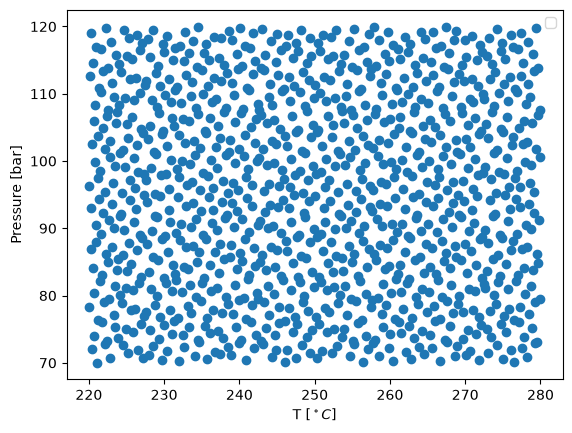

In [18]:
# Feasible points in the design plane; the six flow dimensions are projected out
fig, ax = plt.subplots()
ax.scatter(df.temperature_C, df.pressure_bar)
ax.set(xlabel="T [$^\\circ{C}$]", ylabel="Pressure [bar]")
ax.legend()

In [19]:
# Surrogate targets.  The reaction set has two independent reactions,
#   xi1: CO2 + 3 H2 -> CH3OH + H2O      xi2: CO2 + H2 -> CO + H2O
# so every outlet flow is inlet + stoichiometry * extents; the net predicts the
# extents, duty and pressure drop and the mass balance holds by construction.
STOICH = {"Hydrogen": (-3, -1), "CO": (0, 1), "CO2": (-1, -1),
          "H2O": (1, 1), "Methanol": (1, 0), "Nitrogen": (0, 0)}      # (nu_xi1, nu_xi2)

def outlet_flows(inlet_kgmole_h: dict, xi) -> dict:
    """Outlet component flows from inlet flows and the two extents [kgmole/h]."""
    return {c: inlet_kgmole_h[c] + a * xi[0] + b * xi[1] for c, (a, b) in STOICH.items()}

ok = df[df["converged"]]
X = ok[list(pfr_inlet_bounds)].to_numpy()                 # inputs in box order
Y = pd.DataFrame({
    "xi_meoh_kgmole_h": ok.out_Methanol_kgmole_h - ok.in_Methanol_kgmole_h,
    "xi_co_kgmole_h":   ok.out_CO_kgmole_h - ok.in_CO_kgmole_h,
    "reactor_duty_kW":  ok.reactor_duty_kW,
    "reactor_dP_bar":   ok.reactor_dP_bar,
})
print(f"{len(X)} training points, {X.shape[1]} inputs -> {Y.shape[1]} outputs")
Y.agg(["min", "max"]).T

1024 training points, 8 inputs -> 4 outputs


,min,max
xi_meoh_kgmole_h,172.956375,1422.991879
xi_co_kgmole_h,-584.541218,386.506849
reactor_duty_kW,1325.432957,29645.327926
reactor_dP_bar,0.178286,1.276548


In [20]:
# Hidden width: double until the 5-fold cross-validated error stops improving
width, table = select_width(X, Y.to_numpy())
rmse, Y_oof = cross_validate(X, Y.to_numpy(), hidden=width)
print(f"selected width {width}")
print("CV RMSE per output:")
for name, r, span in zip(Y.columns, rmse, (Y.max() - Y.min())):
    print(f"  {name:18s} {r:9.3f}   {100 * r / span:5.2f} % of range")


  hidden    4  CV rmse/std 0.0758
  hidden    8  CV rmse/std 0.0384
  hidden   16  CV rmse/std 0.0139
  hidden   32  CV rmse/std 0.0095
  hidden   64  CV rmse/std 0.0081
  hidden  128  CV rmse/std 0.0109
selected width 64
CV RMSE per output:
  xi_meoh_kgmole_h       2.291    0.18 % of range
  xi_co_kgmole_h         1.740    0.18 % of range
  reactor_duty_kW       50.000    0.18 % of range
  reactor_dP_bar         0.001    0.11 % of range


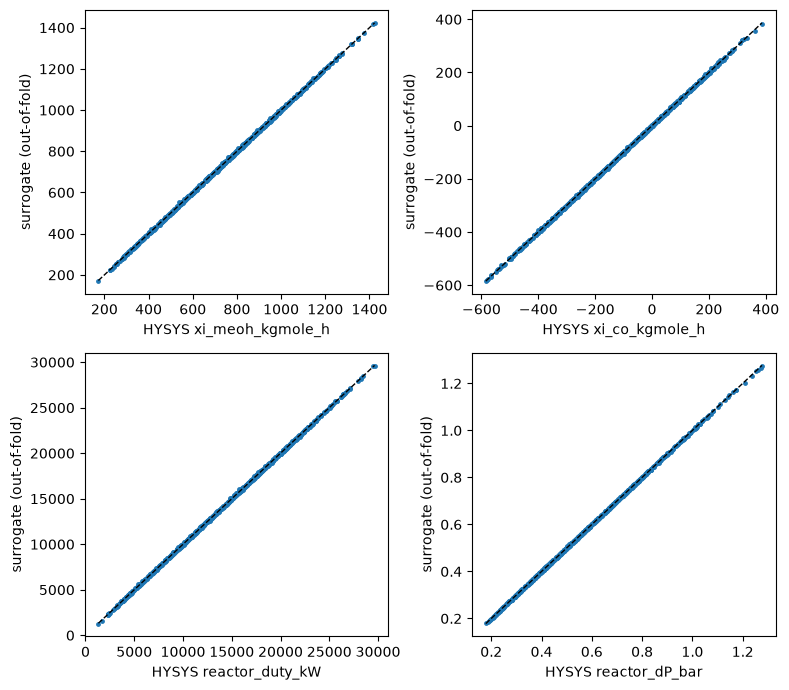

In [21]:
# Final fit on all data, out-of-fold parity plot, export for later embedding
surrogate = fit_mlp(X, Y.to_numpy(), hidden=width)
surrogate.export("pfr_surrogate.txt")

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
for ax, name, y, yhat in zip(axes.flat, Y.columns, Y.to_numpy().T, Y_oof.T):
    ax.scatter(y, yhat, s=6)
    lim = [y.min(), y.max()]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set(xlabel=f"HYSYS {name}", ylabel="surrogate (out-of-fold)")
fig.tight_layout()

In [22]:
# Sanity check on one point: reconstructed outlet vs HYSYS
row = ok.iloc[0]
xi = surrogate(row[list(pfr_inlet_bounds)].to_numpy())
inlet = {c: row[f"in_{c}_kgmole_h"] for c in STOICH}
for c, f in outlet_flows(inlet, xi).items():
    print(f"  {c:9s} surrogate {f:9.2f}   HYSYS {row[f'out_{c}_kgmole_h']:9.2f} kgmole/h")

  Hydrogen  surrogate  13072.79   HYSYS  13071.91 kgmole/h
  CO        surrogate    296.74   HYSYS    297.15 kgmole/h
  CO2       surrogate   1521.97   HYSYS   1521.41 kgmole/h
  H2O       surrogate    790.99   HYSYS    791.56 kgmole/h
  Methanol  surrogate    656.30   HYSYS    656.46 kgmole/h
  Nitrogen  surrogate    208.31   HYSYS    208.31 kgmole/h
